In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

data = torch.load('../results/graph_data.pt', weights_only=False)

# Target: predict betweenness centrality (column index 1) from the OTHER features
y = data.x[:, 1].clone().unsqueeze(1)  # betweenness as target
x_input = data.x[:, [0, 2, 3]]  # degree, closeness, traffic_load only (mask out betweenness)

n_nodes = x_input.shape[0]
perm = torch.randperm(n_nodes)
train_idx = perm[:40]
test_idx = perm[40:]

print("Train nodes:", len(train_idx), "Test nodes:", len(test_idx))

Train nodes: 40 Test nodes: 10


In [4]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim=3, hidden_dim=32, out_dim=16):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.predictor = torch.nn.Linear(out_dim, 1)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        embeddings = self.conv2(h, edge_index)
        out = self.predictor(embeddings)
        return out, embeddings

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out, _ = model(x_input, data.edge_index)
    loss = F.mse_loss(out[train_idx], y[train_idx])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Train MSE = {loss.item():.6f}")

model.eval()
with torch.no_grad():
    out, embeddings = model(x_input, data.edge_index)
    test_loss = F.mse_loss(out[test_idx], y[test_idx])
    print(f"\nFinal Test MSE: {test_loss.item():.6f}")

torch.save(embeddings, '../results/gcn_embeddings.pt')
print("Saved gcn_embeddings.pt — shape:", embeddings.shape)

Epoch 0: Train MSE = 0.003272
Epoch 50: Train MSE = 0.000314
Epoch 100: Train MSE = 0.000037
Epoch 150: Train MSE = 0.000026

Final Test MSE: 0.000055
Saved gcn_embeddings.pt — shape: torch.Size([50, 16])


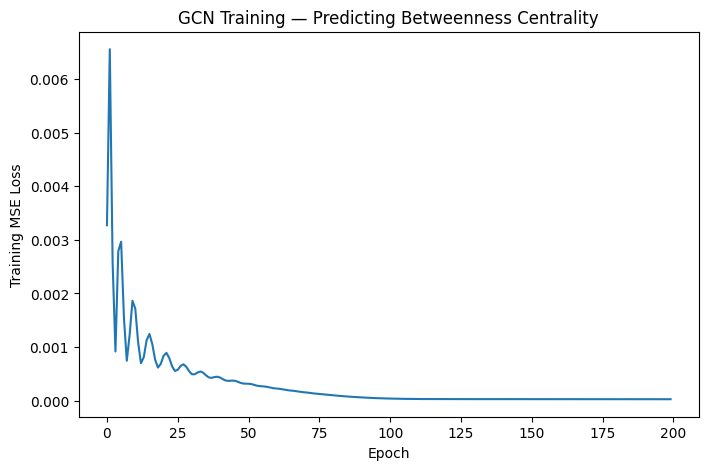

Saved week4_gcn_loss.png


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("GCN Training — Predicting Betweenness Centrality")
plt.savefig("../results/week4_gcn_loss.png", dpi=150)
plt.show()
print("Saved week4_gcn_loss.png")